# 3x Leveraged ETF Rebalancing Strategy

Based on Dr. Lewis A. Glenn's paper "Long-Term Investing in Triple Leveraged ETFs" (SSRN 3722318) and the [SetupAlpha Medium article](https://medium.com/@setupalpha.capital/3x-leveraged-etf-strategy-2-600-return-with-38-drawdown-trading-strategy-rules-f4dad806bc25).

## Strategy Rules:
1. **Universe**: TQQQ (3x Nasdaq-100), TMF (3x 20-Year Treasury)
2. **Allocation**: 50% TQQQ, 50% TMF
3. **Rebalancing**: Every 2 months - rebalance back to 50/50 split
4. **Crash Filter ("Black Swan Filter")**:
   - If TQQQ drops **20% or more** in a single day, exit both positions
   - Move to **cash** (or IEF in original paper)
   - Stay out until TQQQ recovers and **exceeds its pre-crash price**
   - Then return to 50/50 TQQQ/TMF

## Key Insight:
The negative correlation between tech equities and long-duration bonds creates a natural hedge that offsets beta slippage from daily leverage resets.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Resolve project root (parent of notebooks/) so paths work regardless of CWD
NOTEBOOK_DIR = Path(r"c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest\notebooks")
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Set display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"Libraries imported successfully")
print(f"Project root: {PROJECT_ROOT}")

Libraries imported successfully
Project root: c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest


## Load Price Data

Load TQQQ and TMF daily data from parquet file.

In [2]:
# Load data from parquet
df = pd.read_parquet(PROJECT_ROOT / 'equities' / 'triple_leveraged_etfs.parquet')

# Preview
print(f"Total rows: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Tickers: {df['ticker'].unique().tolist()}")
df.head(10)

Total rows: 8284
Date range: 2009-04-16 00:00:00 to 2026-03-03 00:00:00
Tickers: ['TMF', 'TQQQ']


,date,ticker,open,high,low,close,volume
0,2009-04-16,TMF,146.30,147.93,144.93,145.35,4544.00
1,2009-04-17,TMF,143.00,143.25,138.03,138.85,12020.00
2,2009-04-20,TMF,142.90,147.28,142.90,147.28,2701.00
3,2009-04-21,TMF,151.03,152.43,142.78,142.82,6228.00
4,2009-04-22,TMF,142.75,142.75,136.25,137.95,10108.00
5,2009-04-23,TMF,138.12,139.68,136.18,138.68,14387.00
6,2009-04-24,TMF,136.18,136.18,131.75,131.88,20576.00
7,2009-04-27,TMF,135.65,135.74,130.85,135.74,3375.00
8,2009-04-28,TMF,134.30,134.45,126.38,127.97,2750.00
9,2009-04-29,TMF,128.50,131.06,122.17,123.75,7247.00


In [3]:
# Pivot data to wide format for easier analysis
prices = df.pivot(index='date', columns='ticker', values='close').sort_index()

# Filter to common dates (both TQQQ and TMF have data)
prices = prices.dropna()

print(f"Common date range: {prices.index.min()} to {prices.index.max()}")
print(f"Trading days: {len(prices)}")
prices.tail()

Common date range: 2010-02-11 00:00:00 to 2026-03-03 00:00:00
Trading days: 4038


ticker,TMF,TQQQ
date,,
2026-02-25,40.61,51.87
2026-02-26,41.11,50.05
2026-02-27,41.77,49.52
2026-03-02,40.53,49.70
2026-03-03,40.30,48.10


## Calculate Daily Returns

Compute daily returns for both ETFs and identify potential crash days.

In [4]:
# Calculate daily returns
returns = prices.pct_change().dropna()

# Identify crash days (TQQQ drops 20% or more)
CRASH_THRESHOLD = -0.20

crash_days = returns[returns['TQQQ'] <= CRASH_THRESHOLD]
print(f"Number of crash days (TQQQ <= -20%): {len(crash_days)}")
if len(crash_days) > 0:
    print("\nCrash days:")
    print(crash_days[['TQQQ', 'TMF']])

# Show correlation between TQQQ and TMF
correlation = returns['TQQQ'].corr(returns['TMF'])
print(f"\nCorrelation TQQQ vs TMF: {correlation:.4f}")

Number of crash days (TQQQ <= -20%): 3

Crash days:
ticker      TQQQ  TMF
date                 
2020-03-09 -0.20 0.09
2020-03-12 -0.27 0.02
2020-03-16 -0.34 0.17

Correlation TQQQ vs TMF: -0.2237


## Strategy Implementation

Implement the 50/50 TQQQ/TMF strategy with:
- Bimonthly rebalancing (every 2 months)
- Crash filter: exit to cash if TQQQ drops 20%+ in a day
- Re-entry: return to 50/50 when TQQQ exceeds pre-crash price

In [5]:
# Strategy Parameters
REBALANCE_MONTHS = 2       # Rebalance every N months
CRASH_THRESHOLD = -0.20    # Exit if TQQQ drops 20%+ in a day
TARGET_WEIGHT_TQQQ = 0.50  # 50% TQQQ
TARGET_WEIGHT_TMF = 0.50   # 50% TMF
INITIAL_CAPITAL = 100_000  # Starting capital
SLIPPAGE_PCT = 0.0025      # 0.25% slippage per trade (per article)

def run_strategy(prices: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """
    Run the 3x Leveraged ETF strategy.
    
    Returns DataFrame with daily portfolio values and metadata.
    """
    dates = prices.index
    n_days = len(dates)
    
    # State tracking
    portfolio_values = []
    weights_history = []
    in_cash = False
    pre_crash_tqqq_price = None  # Track for re-entry condition
    last_rebalance_month = None
    
    # Initialize capital
    capital = INITIAL_CAPITAL
    shares_tqqq = 0.0
    shares_tmf = 0.0
    
    for i, date in enumerate(dates):
        tqqq_price = prices.loc[date, 'TQQQ']
        tmf_price = prices.loc[date, 'TMF']
        
        # Calculate daily return from previous day's holdings
        if i > 0:
            tqqq_ret = returns.loc[date, 'TQQQ'] if date in returns.index else 0
            tmf_ret = returns.loc[date, 'TMF'] if date in returns.index else 0
            
            # Previous day's value
            prev_date = dates[i-1]
            prev_tqqq_price = prices.loc[prev_date, 'TQQQ']
            prev_tmf_price = prices.loc[prev_date, 'TMF']
            
            if not in_cash:
                # Update share values
                tqqq_value = shares_tqqq * tqqq_price
                tmf_value = shares_tmf * tmf_price
                capital = tqqq_value + tmf_value
        
        # Check for crash condition
        if i > 0 and not in_cash:
            tqqq_ret = returns.loc[date, 'TQQQ'] if date in returns.index else 0
            if tqqq_ret <= CRASH_THRESHOLD:
                # CRASH! Exit to cash
                in_cash = True
                pre_crash_tqqq_price = prices.loc[dates[i-1], 'TQQQ']  # Previous day's price
                
                # Liquidate with slippage
                capital = capital * (1 - SLIPPAGE_PCT)
                shares_tqqq = 0.0
                shares_tmf = 0.0
                
        # Check for re-entry condition
        if in_cash and pre_crash_tqqq_price is not None:
            if tqqq_price > pre_crash_tqqq_price:
                # Re-enter the market
                in_cash = False
                pre_crash_tqqq_price = None
                
                # Allocate 50/50 with slippage
                capital = capital * (1 - SLIPPAGE_PCT)
                shares_tqqq = (capital * TARGET_WEIGHT_TQQQ) / tqqq_price
                shares_tmf = (capital * TARGET_WEIGHT_TMF) / tmf_price
                last_rebalance_month = (date.year, date.month)
        
        # First day initialization
        if i == 0 and not in_cash:
            shares_tqqq = (capital * TARGET_WEIGHT_TQQQ) / tqqq_price
            shares_tmf = (capital * TARGET_WEIGHT_TMF) / tmf_price
            last_rebalance_month = (date.year, date.month)
        
        # Check for rebalancing (bimonthly)
        current_month = (date.year, date.month)
        if not in_cash and last_rebalance_month is not None:
            months_diff = (current_month[0] - last_rebalance_month[0]) * 12 + \
                          (current_month[1] - last_rebalance_month[1])
            
            if months_diff >= REBALANCE_MONTHS:
                # Rebalance to 50/50
                tqqq_value = shares_tqqq * tqqq_price
                tmf_value = shares_tmf * tmf_price
                total_value = tqqq_value + tmf_value
                
                # Apply slippage for rebalancing
                rebal_cost = abs(tqqq_value - total_value * TARGET_WEIGHT_TQQQ) * SLIPPAGE_PCT
                total_value -= rebal_cost
                
                shares_tqqq = (total_value * TARGET_WEIGHT_TQQQ) / tqqq_price
                shares_tmf = (total_value * TARGET_WEIGHT_TMF) / tmf_price
                capital = total_value
                last_rebalance_month = current_month
        
        # Calculate current portfolio value
        if in_cash:
            port_value = capital
            w_tqqq, w_tmf = 0.0, 0.0
        else:
            tqqq_value = shares_tqqq * tqqq_price
            tmf_value = shares_tmf * tmf_price
            port_value = tqqq_value + tmf_value
            w_tqqq = tqqq_value / port_value if port_value > 0 else 0
            w_tmf = tmf_value / port_value if port_value > 0 else 0
        
        portfolio_values.append({
            'date': date,
            'portfolio_value': port_value,
            'weight_tqqq': w_tqqq,
            'weight_tmf': w_tmf,
            'in_cash': in_cash,
            'shares_tqqq': shares_tqqq,
            'shares_tmf': shares_tmf,
        })
    
    return pd.DataFrame(portfolio_values).set_index('date')

# Run the strategy
strategy_results = run_strategy(prices, returns)
print(f"Strategy period: {strategy_results.index.min()} to {strategy_results.index.max()}")
print(f"Initial value: ${INITIAL_CAPITAL:,}")
print(f"Final value: ${strategy_results['portfolio_value'].iloc[-1]:,.0f}")
strategy_results.tail()

Strategy period: 2010-02-11 00:00:00 to 2026-03-03 00:00:00
Initial value: $100,000
Final value: $3,497,441


,portfolio_value,weight_tqqq,weight_tmf,in_cash,shares_tqqq,shares_tmf
date,,,,,,
2026-02-25,3641396.28,0.48,0.52,False,33354.43,47064.81
2026-02-26,3604223.62,0.46,0.54,False,33354.43,47064.81
2026-02-27,3617608.55,0.46,0.54,False,33354.43,47064.81
2026-03-02,3564939.71,0.50,0.50,False,35864.58,43979.02
2026-03-03,3497441.19,0.49,0.51,False,35864.58,43979.02


## Per-Asset Signal Analysis: TQQQ vs TMF

Break down each "signal" (asset) individually — cumulative returns, Sharpe, drawdowns, contribution to the portfolio — then show how combining them at 50/50 adds value.

In [22]:
# ====== Per-Asset Returns & Metrics ======

# Individual asset equity curves (buy-and-hold $100K each)
tqqq_equity = (prices['TQQQ'] / prices['TQQQ'].iloc[0]) * INITIAL_CAPITAL
tmf_equity  = (prices['TMF'] / prices['TMF'].iloc[0]) * INITIAL_CAPITAL

# 50/50 buy-hold (no rebalance)
bh5050_equity = 0.5 * tqqq_equity + 0.5 * tmf_equity

# Strategy equity
strat_equity = strategy_results['portfolio_value']

# Daily returns for each
tqqq_rets = prices['TQQQ'].pct_change().dropna()
tmf_rets  = prices['TMF'].pct_change().dropna()
bh5050_rets = bh5050_equity.pct_change().dropna()
strat_rets  = strat_equity.pct_change().dropna()

# Align all to common index
common_idx = tqqq_rets.index.intersection(tmf_rets.index).intersection(strat_rets.index)
tqqq_rets = tqqq_rets.loc[common_idx]
tmf_rets  = tmf_rets.loc[common_idx]
bh5050_rets = bh5050_rets.loc[common_idx]
strat_rets  = strat_rets.loc[common_idx]

# ── Metrics table ──
def asset_metrics(rets, name, rf=0.02):
    ann_ret = (1 + rets.mean()) ** 252 - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe  = (ann_ret - rf) / ann_vol if ann_vol > 0 else 0
    sortino_denom = rets[rets < 0].std() * np.sqrt(252)
    sortino = (ann_ret - rf) / sortino_denom if sortino_denom > 0 else 0
    cum = (1 + rets).cumprod()
    dd  = (cum / cum.cummax() - 1).min()
    skew_val = rets.skew()
    kurt_val = rets.kurtosis()
    # Daily hit rate
    hit = (rets > 0).mean()
    # Avg win / avg loss
    avg_win  = rets[rets > 0].mean() * 100 if (rets > 0).any() else 0
    avg_loss = rets[rets < 0].mean() * 100 if (rets < 0).any() else 0
    return {
        'Ann. Return (%)': ann_ret * 100,
        'Ann. Vol (%)': ann_vol * 100,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Max DD (%)': dd * 100,
        'Hit Rate (%)': hit * 100,
        'Avg Win (%)': avg_win,
        'Avg Loss (%)': avg_loss,
        'Skew': skew_val,
        'Kurtosis': kurt_val,
        'Total Return (%)': ((1 + rets).prod() - 1) * 100,
    }

metrics_table = pd.DataFrame({
    'TQQQ': asset_metrics(tqqq_rets, 'TQQQ'),
    'TMF': asset_metrics(tmf_rets, 'TMF'),
    '50/50 Buy-Hold': asset_metrics(bh5050_rets, '50/50'),
    'Strategy (Rebal+Filter)': asset_metrics(strat_rets, 'Strategy'),
})

print("=" * 80)
print("PER-ASSET SIGNAL METRICS")
print("=" * 80)
print()
for idx in metrics_table.index:
    vals = "  |  ".join(f"{col}: {metrics_table.loc[idx, col]:>8.2f}" for col in metrics_table.columns)
    print(f"  {idx:<22s}  {vals}")

metrics_table

PER-ASSET SIGNAL METRICS

  Ann. Return (%)         TQQQ:    69.04  |  TMF:     6.07  |  50/50 Buy-Hold:    53.56  |  Strategy (Rebal+Filter):    31.38
  Ann. Vol (%)            TQQQ:    60.99  |  TMF:    44.59  |  50/50 Buy-Hold:    51.71  |  Strategy (Rebal+Filter):    31.94
  Sharpe                  TQQQ:     1.10  |  TMF:     0.09  |  50/50 Buy-Hold:     1.00  |  Strategy (Rebal+Filter):     0.92
  Sortino                 TQQQ:     1.41  |  TMF:     0.14  |  50/50 Buy-Hold:     1.24  |  Strategy (Rebal+Filter):     1.26
  Max DD (%)              TQQQ:   -81.75  |  TMF:   -93.33  |  50/50 Buy-Hold:   -81.60  |  Strategy (Rebal+Filter):   -76.77
  Hit Rate (%)            TQQQ:    55.81  |  TMF:    51.99  |  50/50 Buy-Hold:    56.18  |  Strategy (Rebal+Filter):    54.55
  Avg Win (%)             TQQQ:     2.58  |  TMF:     2.06  |  50/50 Buy-Hold:     2.10  |  Strategy (Rebal+Filter):     1.45
  Avg Loss (%)            TQQQ:    -2.80  |  TMF:    -2.20  |  50/50 Buy-Hold:    -2.30  |  

,TQQQ,TMF,50/50 Buy-Hold,Strategy (Rebal+Filter)
Ann. Return (%),69.04,6.07,53.56,31.38
Ann. Vol (%),60.99,44.59,51.71,31.94
Sharpe,1.10,0.09,1.00,0.92
Sortino,1.41,0.14,1.24,1.26
Max DD (%),-81.75,-93.33,-81.60,-76.77
Hit Rate (%),55.81,51.99,56.18,54.55
Avg Win (%),2.58,2.06,2.10,1.45
Avg Loss (%),-2.80,-2.20,-2.30,-1.54
Skew,-0.22,0.00,-0.21,-0.17
Kurtosis,7.01,3.14,8.98,3.72


In [23]:
# ====== Per-Asset Cumulative Returns & Rolling Sharpe — Plotly ======

# Cumulative returns (not equity — just percentage growth)
tqqq_cum = (1 + tqqq_rets).cumprod() - 1
tmf_cum  = (1 + tmf_rets).cumprod() - 1
bh5050_cum = (1 + bh5050_rets).cumprod() - 1
strat_cum  = (1 + strat_rets).cumprod() - 1

# Rolling 252-day Sharpe (annualised)
window = 252
tqqq_roll_sharpe  = (tqqq_rets.rolling(window).mean() / tqqq_rets.rolling(window).std()) * np.sqrt(252)
tmf_roll_sharpe   = (tmf_rets.rolling(window).mean() / tmf_rets.rolling(window).std()) * np.sqrt(252)
bh5050_roll_sharpe = (bh5050_rets.rolling(window).mean() / bh5050_rets.rolling(window).std()) * np.sqrt(252)
strat_roll_sharpe  = (strat_rets.rolling(window).mean() / strat_rets.rolling(window).std()) * np.sqrt(252)

# Rolling 90-day correlation (TQQQ vs TMF)
roll_corr = tqqq_rets.rolling(90).corr(tmf_rets)

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=('Cumulative Returns (%)',
                                    'Rolling 1Y Sharpe Ratio',
                                    'Rolling 90d Correlation (TQQQ vs TMF)'),
                    row_heights=[0.40, 0.35, 0.25])

colors = {'TQQQ': '#2196F3', 'TMF': '#4CAF50', '50/50 BH': '#FF9800', 'Strategy': '#9C27B0'}

# Panel 1: Cumulative returns
for name, series, color, dash in [
    ('TQQQ', tqqq_cum, colors['TQQQ'], None),
    ('TMF', tmf_cum, colors['TMF'], None),
    ('50/50 Buy-Hold', bh5050_cum, colors['50/50 BH'], 'dash'),
    ('Strategy', strat_cum, colors['Strategy'], 'dot'),
]:
    fig.add_trace(go.Scatter(x=series.index, y=series * 100, name=name,
        line=dict(color=color, width=2, dash=dash),
        hovertemplate=f'{name}: %{{y:.0f}}%<extra></extra>'), row=1, col=1)
fig.update_yaxes(title_text='Cumul. Return (%)', row=1, col=1)

# Panel 2: Rolling Sharpe
for name, series, color, dash in [
    ('TQQQ', tqqq_roll_sharpe, colors['TQQQ'], None),
    ('TMF', tmf_roll_sharpe, colors['TMF'], None),
    ('50/50 BH', bh5050_roll_sharpe, colors['50/50 BH'], 'dash'),
    ('Strategy', strat_roll_sharpe, colors['Strategy'], 'dot'),
]:
    fig.add_trace(go.Scatter(x=series.index, y=series, name=name, showlegend=False,
        line=dict(color=color, width=1.5, dash=dash),
        hovertemplate=f'{name}: %{{y:.2f}}<extra></extra>'), row=2, col=1)
fig.add_hline(y=0, line_dash='solid', line_color='gray', opacity=0.3, row=2, col=1)
fig.update_yaxes(title_text='Sharpe (rolling 1Y)', row=2, col=1)

# Panel 3: Rolling correlation
fig.add_trace(go.Scatter(x=roll_corr.index, y=roll_corr,
    name='TQQQ–TMF Corr', line=dict(color='#E91E63', width=1.5),
    fill='tozeroy', fillcolor='rgba(233,30,99,0.1)',
    hovertemplate='Corr: %{y:.3f}<extra></extra>'), row=3, col=1)
fig.add_hline(y=0, line_dash='solid', line_color='gray', opacity=0.3, row=3, col=1)
fig.update_yaxes(title_text='Correlation', range=[-1, 1], row=3, col=1)

fig.update_layout(height=750, template='plotly_white', hovermode='x unified',
                  title='Per-Asset Signal Analysis: Returns, Sharpe & Correlation',
                  legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

In [25]:
# ====== PnL Contribution & Drawdown Decomposition ======

# Strategy PnL attribution: how much did each leg contribute?
# Weight history from strategy_results
w_tqqq_ts = strategy_results['weight_tqqq'].reindex(common_idx).ffill()
w_tmf_ts  = strategy_results['weight_tmf'].reindex(common_idx).ffill()

# Contribution = weight_prev_day × asset_return
tqqq_contrib = (w_tqqq_ts.shift(1) * tqqq_rets).dropna()
tmf_contrib  = (w_tmf_ts.shift(1) * tmf_rets).dropna()
total_contrib = tqqq_contrib + tmf_contrib

# Cumulative PnL contribution
tqqq_cum_pnl = tqqq_contrib.cumsum() * 100
tmf_cum_pnl  = tmf_contrib.cumsum() * 100
total_cum_pnl = total_contrib.cumsum() * 100

# Drawdowns per asset (standalone)
tqqq_dd = ((1 + tqqq_rets).cumprod() / (1 + tqqq_rets).cumprod().cummax() - 1) * 100
tmf_dd  = ((1 + tmf_rets).cumprod() / (1 + tmf_rets).cumprod().cummax() - 1) * 100
strat_dd = ((1 + strat_rets).cumprod() / (1 + strat_rets).cumprod().cummax() - 1) * 100

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                    subplot_titles=('Cumulative PnL Contribution to Strategy (%)',
                                    'Drawdowns: Per-Asset vs Combined Strategy'))

# Panel 1: PnL contribution (stacked area)
fig.add_trace(go.Scatter(x=tqqq_cum_pnl.index, y=tqqq_cum_pnl,
    name='TQQQ contribution', stackgroup='pnl',
    line=dict(width=0.5, color='#2196F3'), fillcolor='rgba(33,150,243,0.5)',
    hovertemplate='TQQQ: %{y:.1f}%<extra></extra>'), row=1, col=1)
fig.add_trace(go.Scatter(x=tmf_cum_pnl.index, y=tmf_cum_pnl,
    name='TMF contribution', stackgroup='pnl',
    line=dict(width=0.5, color='#4CAF50'), fillcolor='rgba(76,175,80,0.5)',
    hovertemplate='TMF: %{y:.1f}%<extra></extra>'), row=1, col=1)
fig.add_trace(go.Scatter(x=total_cum_pnl.index, y=total_cum_pnl,
    name='Total (sum)', line=dict(color='#9C27B0', width=2, dash='dot'),
    hovertemplate='Total: %{y:.1f}%<extra></extra>'), row=1, col=1)
fig.update_yaxes(title_text='Cumul. PnL (%)', row=1, col=1)

# Panel 2: Drawdowns
fig.add_trace(go.Scatter(x=tqqq_dd.index, y=tqqq_dd,
    name='TQQQ DD', line=dict(color='#2196F3', width=1), opacity=0.6,
    hovertemplate='TQQQ: %{y:.1f}%<extra></extra>'), row=2, col=1)
fig.add_trace(go.Scatter(x=tmf_dd.index, y=tmf_dd,
    name='TMF DD', line=dict(color='#4CAF50', width=1), opacity=0.6,
    hovertemplate='TMF: %{y:.1f}%<extra></extra>'), row=2, col=1)
fig.add_trace(go.Scatter(x=strat_dd.index, y=strat_dd,
    name='Strategy DD', line=dict(color='#9C27B0', width=2),
    fill='tozeroy', fillcolor='rgba(156,39,176,0.15)',
    hovertemplate='Strategy: %{y:.1f}%<extra></extra>'), row=2, col=1)
fig.update_yaxes(title_text='Drawdown (%)', row=2, col=1)

fig.update_layout(height=650, template='plotly_white', hovermode='x unified',
                  title='PnL Attribution & Drawdown Decomposition',
                  legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

# Summary: Which asset drove returns?
print(f"Total PnL contribution:  TQQQ {tqqq_cum_pnl.iloc[-1]:+.0f}%  |  TMF {tmf_cum_pnl.iloc[-1]:+.0f}%  |  Combined {total_cum_pnl.iloc[-1]:+.0f}%")
print(f"Correlation benefit:     Strategy Sharpe {metrics_table.loc['Sharpe', 'Strategy (Rebal+Filter)']:.2f} "
      f"vs weighted avg {0.5 * metrics_table.loc['Sharpe', 'TQQQ'] + 0.5 * metrics_table.loc['Sharpe', 'TMF']:.2f}")
print(f"Max DD improvement:      Strategy {metrics_table.loc['Max DD (%)', 'Strategy (Rebal+Filter)']:.1f}% "
      f"vs TQQQ {metrics_table.loc['Max DD (%)', 'TQQQ']:.1f}% / TMF {metrics_table.loc['Max DD (%)', 'TMF']:.1f}%")

Total PnL contribution:  TQQQ +381%  |  TMF +57%  |  Combined +439%
Correlation benefit:     Strategy Sharpe 0.92 vs weighted avg 0.60
Max DD improvement:      Strategy -76.8% vs TQQQ -81.8% / TMF -93.3%


In [26]:
# ====== Annual Returns & Sharpe Per Asset ======

# Build yearly returns for each
all_rets = pd.DataFrame({'TQQQ': tqqq_rets, 'TMF': tmf_rets, '50/50 BH': bh5050_rets,
                          'Strategy': strat_rets}).dropna()

yearly_asset_rets = all_rets.groupby(all_rets.index.year).apply(
    lambda g: pd.Series({col: (1 + g[col]).prod() - 1 for col in g.columns})
) * 100

yearly_asset_sharpe = all_rets.groupby(all_rets.index.year).apply(
    lambda g: pd.Series({col: (g[col].mean() / g[col].std() * np.sqrt(252)) if g[col].std() > 0 else 0
                         for col in g.columns})
)

# Plot: Grouped bar chart of annual returns
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.10,
                    subplot_titles=('Annual Returns by Asset (%)', 'Annual Sharpe by Asset'))

for col, color in [('TQQQ', '#2196F3'), ('TMF', '#4CAF50'), ('50/50 BH', '#FF9800'), ('Strategy', '#9C27B0')]:
    fig.add_trace(go.Bar(x=yearly_asset_rets.index.astype(str), y=yearly_asset_rets[col],
        name=col, marker_color=color, opacity=0.8,
        hovertemplate=f'{col}: %{{y:.1f}}%<extra></extra>'), row=1, col=1)

for col, color in [('TQQQ', '#2196F3'), ('TMF', '#4CAF50'), ('50/50 BH', '#FF9800'), ('Strategy', '#9C27B0')]:
    fig.add_trace(go.Bar(x=yearly_asset_sharpe.index.astype(str), y=yearly_asset_sharpe[col],
        name=col, marker_color=color, opacity=0.8, showlegend=False,
        hovertemplate=f'{col}: %{{y:.2f}}<extra></extra>'), row=2, col=1)

fig.add_hline(y=0, line_dash='solid', line_color='gray', opacity=0.3, row=1, col=1)
fig.add_hline(y=0, line_dash='solid', line_color='gray', opacity=0.3, row=2, col=1)
fig.update_yaxes(title_text='Return (%)', row=1, col=1)
fig.update_yaxes(title_text='Sharpe', row=2, col=1)
fig.update_layout(height=600, template='plotly_white', barmode='group',
                  title='Annual Returns & Sharpe: Per-Asset Decomposition',
                  legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

# Print yearly correlation of signals
yearly_corr = all_rets.groupby(all_rets.index.year).apply(
    lambda g: g['TQQQ'].corr(g['TMF']))
print("Annual TQQQ–TMF correlation:")
for yr, corr in yearly_corr.items():
    marker = "🟢" if corr < -0.1 else ("🔴" if corr > 0.1 else "⚪")
    print(f"  {yr}:  {corr:+.3f}  {marker}")

Annual TQQQ–TMF correlation:
  2010:  -0.546  🟢
  2011:  -0.618  🟢
  2012:  -0.559  🟢
  2013:  -0.198  🟢
  2014:  -0.408  🟢
  2015:  -0.326  🟢
  2016:  -0.285  🟢
  2017:  -0.156  🟢
  2018:  -0.229  🟢
  2019:  -0.406  🟢
  2020:  -0.387  🟢
  2021:  +0.068  ⚪
  2022:  +0.084  ⚪
  2023:  +0.143  🔴
  2024:  +0.003  ⚪
  2025:  +0.040  ⚪
  2026:  -0.053  ⚪


## Performance Metrics

Calculate key performance metrics: CAGR, Sharpe ratio, max drawdown, etc.

In [6]:
def calculate_metrics(portfolio_values: pd.Series, risk_free_rate: float = 0.02) -> dict:
    """Calculate key performance metrics."""
    
    # Daily returns
    daily_returns = portfolio_values.pct_change().dropna()
    
    # CAGR
    years = (portfolio_values.index[-1] - portfolio_values.index[0]).days / 365.25
    total_return = portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1
    cagr = (1 + total_return) ** (1/years) - 1
    
    # Volatility (annualized)
    volatility = daily_returns.std() * np.sqrt(252)
    
    # Sharpe ratio
    excess_return = cagr - risk_free_rate
    sharpe = excess_return / volatility if volatility > 0 else 0
    
    # Sortino ratio (downside deviation)
    downside_returns = daily_returns[daily_returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = excess_return / downside_std if downside_std > 0 else 0
    
    # Max drawdown
    cummax = portfolio_values.cummax()
    drawdown = (portfolio_values - cummax) / cummax
    max_drawdown = drawdown.min()
    
    # MAR ratio (CAGR / max DD)
    mar_ratio = abs(cagr / max_drawdown) if max_drawdown != 0 else float('inf')
    
    return {
        'Years': years,
        'Total Return': total_return * 100,
        'CAGR': cagr * 100,
        'Volatility': volatility * 100,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown': max_drawdown * 100,
        'MAR Ratio': mar_ratio,
    }

# Calculate strategy metrics
strategy_metrics = calculate_metrics(strategy_results['portfolio_value'])

# Also calculate buy-and-hold benchmarks
# 1. 100% TQQQ only
tqqq_bh = (prices['TQQQ'] / prices['TQQQ'].iloc[0]) * INITIAL_CAPITAL
tqqq_metrics = calculate_metrics(tqqq_bh)

# 2. 50/50 TQQQ/TMF buy-and-hold (no rebalancing)
simple_50_50 = (
    0.5 * (prices['TQQQ'] / prices['TQQQ'].iloc[0]) + 
    0.5 * (prices['TMF'] / prices['TMF'].iloc[0])
) * INITIAL_CAPITAL
simple_5050_metrics = calculate_metrics(simple_50_50)

# Display metrics comparison
metrics_df = pd.DataFrame({
    'Strategy (Rebal+Filter)': strategy_metrics,
    '50/50 Buy-Hold': simple_5050_metrics,
    'TQQQ Only': tqqq_metrics,
})

print("=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)
for metric in metrics_df.index:
    print(f"\n{metric}:")
    for col in metrics_df.columns:
        val = metrics_df.loc[metric, col]
        if metric in ['Total Return', 'CAGR', 'Volatility', 'Max Drawdown']:
            print(f"  {col}: {val:.2f}%")
        else:
            print(f"  {col}: {val:.2f}")

metrics_df

PERFORMANCE COMPARISON

Years:
  Strategy (Rebal+Filter): 16.05
  50/50 Buy-Hold: 16.05
  TQQQ Only: 16.05

Total Return:
  Strategy (Rebal+Filter): 3397.44%
  50/50 Buy-Hold: 11044.88%
  TQQQ Only: 22137.63%

CAGR:
  Strategy (Rebal+Filter): 24.78%
  50/50 Buy-Hold: 34.12%
  TQQQ Only: 40.02%

Volatility:
  Strategy (Rebal+Filter): 31.94%
  50/50 Buy-Hold: 51.71%
  TQQQ Only: 60.99%

Sharpe Ratio:
  Strategy (Rebal+Filter): 0.71
  50/50 Buy-Hold: 0.62
  TQQQ Only: 0.62

Sortino Ratio:
  Strategy (Rebal+Filter): 0.98
  50/50 Buy-Hold: 0.77
  TQQQ Only: 0.80

Max Drawdown:
  Strategy (Rebal+Filter): -76.77%
  50/50 Buy-Hold: -81.60%
  TQQQ Only: -81.75%

MAR Ratio:
  Strategy (Rebal+Filter): 0.32
  50/50 Buy-Hold: 0.42
  TQQQ Only: 0.49


,Strategy (Rebal+Filter),50/50 Buy-Hold,TQQQ Only
Years,16.05,16.05,16.05
Total Return,3397.44,11044.88,22137.63
CAGR,24.78,34.12,40.02
Volatility,31.94,51.71,60.99
Sharpe Ratio,0.71,0.62,0.62
Sortino Ratio,0.98,0.77,0.80
Max Drawdown,-76.77,-81.60,-81.75
MAR Ratio,0.32,0.42,0.49


## Visualize Results

Plot cumulative returns, drawdowns, and weight allocations.

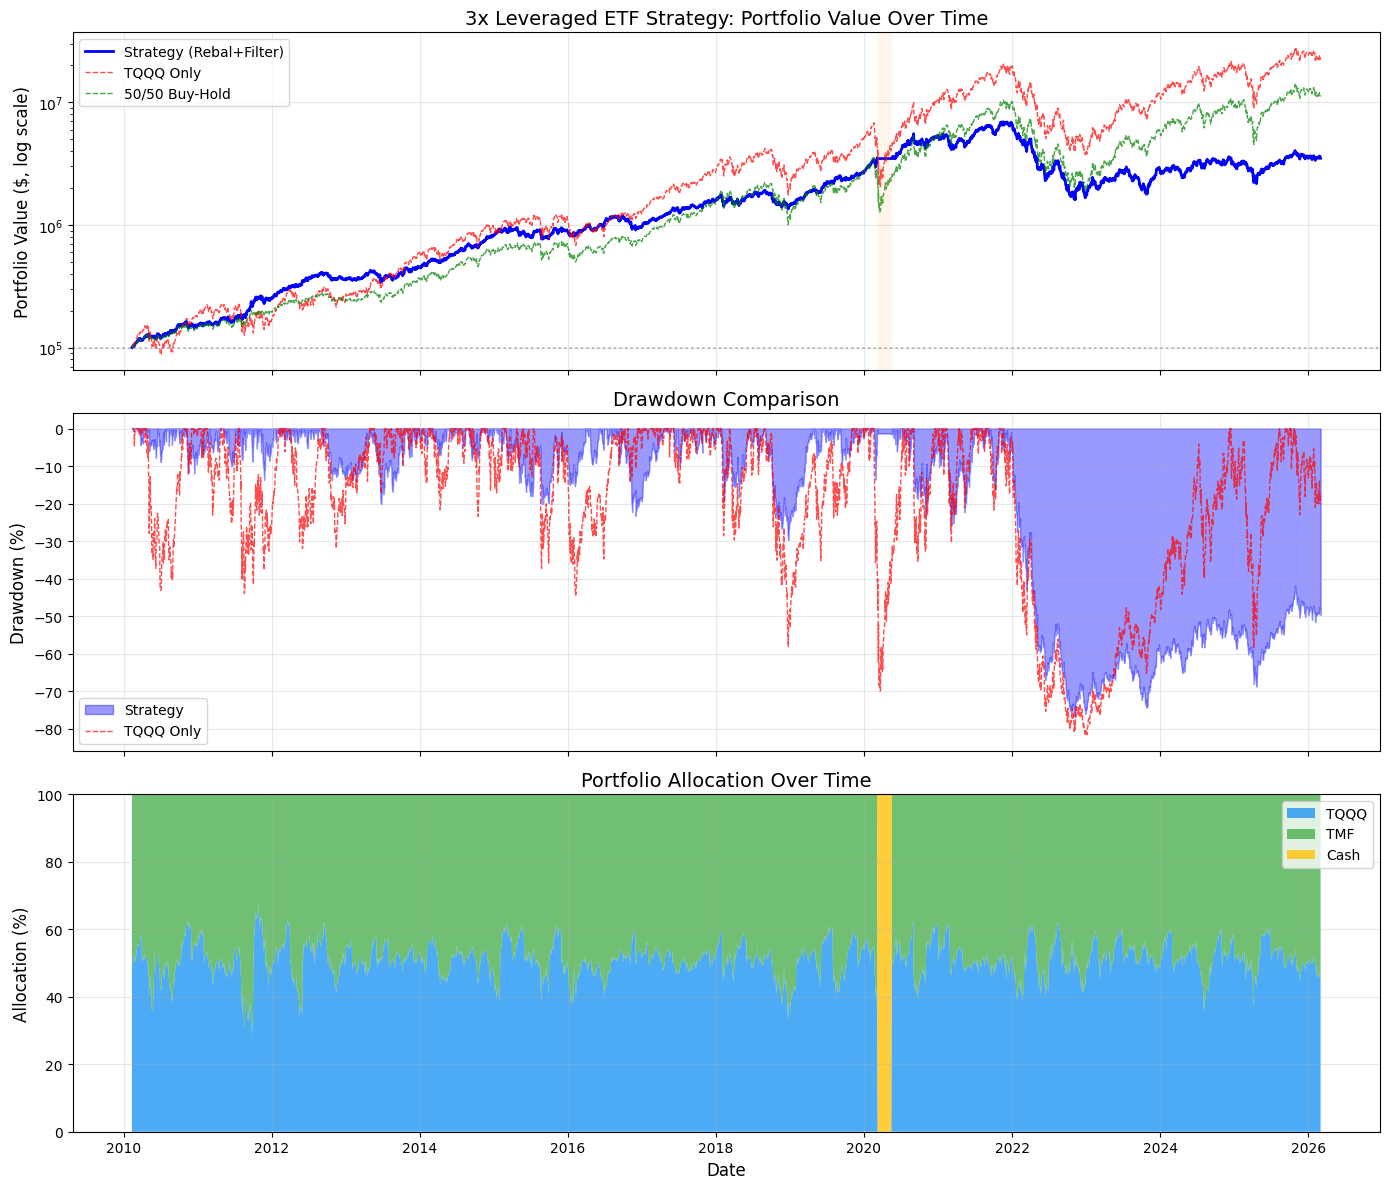

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Portfolio Value (log scale)
ax1 = axes[0]
ax1.semilogy(strategy_results.index, strategy_results['portfolio_value'], 
             label='Strategy (Rebal+Filter)', linewidth=2, color='blue')
ax1.semilogy(prices.index, tqqq_bh, 
             label='TQQQ Only', linewidth=1, alpha=0.7, color='red', linestyle='--')
ax1.semilogy(prices.index, simple_50_50, 
             label='50/50 Buy-Hold', linewidth=1, alpha=0.7, color='green', linestyle='--')

ax1.axhline(INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5)
ax1.set_ylabel('Portfolio Value ($, log scale)', fontsize=12)
ax1.set_title('3x Leveraged ETF Strategy: Portfolio Value Over Time', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Mark crash periods (when in cash)
cash_periods = strategy_results[strategy_results['in_cash']]
for idx in cash_periods.index:
    ax1.axvline(idx, color='orange', alpha=0.01)

# 2. Drawdown
ax2 = axes[1]
cummax_strat = strategy_results['portfolio_value'].cummax()
dd_strat = (strategy_results['portfolio_value'] - cummax_strat) / cummax_strat * 100

cummax_tqqq = tqqq_bh.cummax()
dd_tqqq = (tqqq_bh - cummax_tqqq) / cummax_tqqq * 100

ax2.fill_between(dd_strat.index, dd_strat, 0, alpha=0.4, label='Strategy', color='blue')
ax2.plot(dd_tqqq.index, dd_tqqq, label='TQQQ Only', linewidth=1, alpha=0.7, color='red', linestyle='--')
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.set_title('Drawdown Comparison', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

# 3. Weight allocation
ax3 = axes[2]
ax3.stackplot(strategy_results.index, 
              strategy_results['weight_tqqq'] * 100, 
              strategy_results['weight_tmf'] * 100,
              (1 - strategy_results['weight_tqqq'] - strategy_results['weight_tmf']) * 100,
              labels=['TQQQ', 'TMF', 'Cash'],
              colors=['#2196F3', '#4CAF50', '#FFC107'],
              alpha=0.8)
ax3.set_ylabel('Allocation (%)', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.set_title('Portfolio Allocation Over Time', fontsize=14)
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Monthly Returns Heatmap

Visualize returns by month and year.

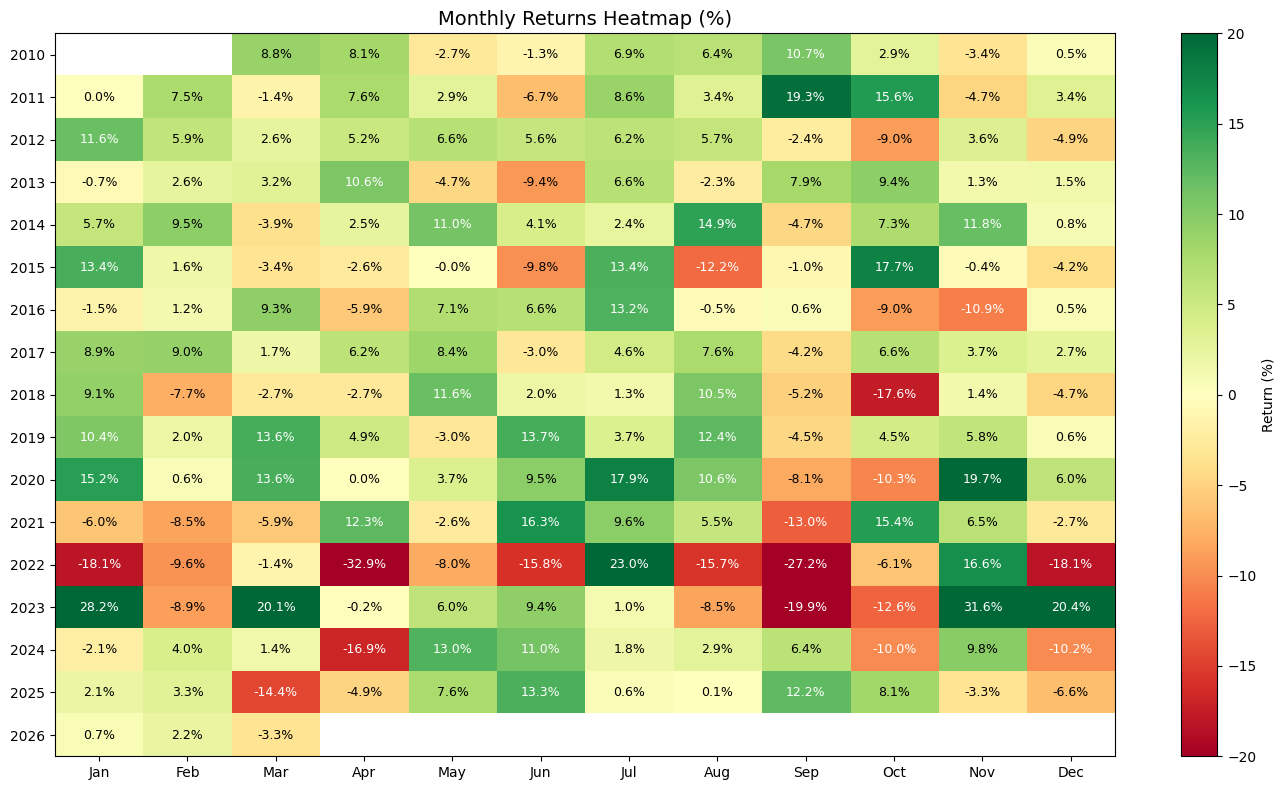


Yearly Returns:
date
2010    51.73
2011    64.40
2012    40.78
2013    23.40
2014    80.11
2015     7.05
2016     9.94
2017    62.24
2018    -9.12
2019    80.14
2020    95.38
2021    27.79
2022   -73.74
2023    63.34
2024    10.50
2025    15.48
2026     0.15


In [8]:
# Calculate monthly returns
strategy_results['month'] = strategy_results.index.to_period('M')
monthly_rets = strategy_results.groupby('month')['portfolio_value'].last().pct_change() * 100

# Create pivot table for heatmap
monthly_df = pd.DataFrame({
    'Year': monthly_rets.index.year,
    'Month': monthly_rets.index.month,
    'Return': monthly_rets.values
}).dropna()

heatmap_data = monthly_df.pivot(index='Year', columns='Month', values='Return')
heatmap_data.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-20, vmax=20)

# Labels
ax.set_xticks(range(12))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Add text annotations
for i in range(len(heatmap_data.index)):
    for j in range(12):
        val = heatmap_data.iloc[i, j]
        if not np.isnan(val):
            color = 'white' if abs(val) > 10 else 'black'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', color=color, fontsize=9)

ax.set_title('Monthly Returns Heatmap (%)', fontsize=14)
plt.colorbar(im, ax=ax, label='Return (%)')
plt.tight_layout()
plt.show()

# Yearly summary
yearly_rets = strategy_results.groupby(strategy_results.index.year)['portfolio_value'].apply(
    lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100
)
print("\nYearly Returns:")
print(yearly_rets.to_string())

---

## DSL Strategy Implementation (QuantDSL) — Actually Running It

Now let's express this strategy in the QuantDSL framework and **actually run it** through the backtest engine.

**Mapping to the DSL:**
- Universe: 2 instruments (TQQQ, TMF) via `static_instruments`
- Factor: 1-day `ReturnFactor` (used for ranking/eligibility)
- Signals: `NotNull` + `CrossSectionRank` → `TopN(n=2)` selects both instruments
- Portfolio: `LongShortPortfolio` with `target_gross_leverage=1.0`, `target_net_exposure=1.0` → **long-only** 50/50

**Limitation:** The crash filter (stateful regime switching) can't be expressed in the current signal DSL, so this tests the **core rebalancing allocation** only.

In [9]:
import sys, os

# Use absolute path to the btest project root (parent of notebooks/)
project_root = r"c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest"
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
# Make sure the working directory is the project root so parquet:// resolves correctly
os.chdir(project_root)

print(f"Project root: {project_root}")
print(f"Working dir:  {os.getcwd()}")

Project root: c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest
Working dir:  c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest


In [10]:
# Build the DSL Strategy object
from quantdsl_backtest.dsl.strategy import Strategy
from quantdsl_backtest.dsl.data_config import DataConfig
from quantdsl_backtest.dsl.universe import Universe, HasHistory
from quantdsl_backtest.dsl.factors import ReturnFactor, VolatilityFactor
from quantdsl_backtest.dsl.signals import (
    CrossSectionRank, NotNull, And, MaskFromBoolean, LessEqual, Quantile,
)
from quantdsl_backtest.dsl.portfolio import (
    LongShortPortfolio, Book, TopN, BottomN, EqualWeight,
)
from quantdsl_backtest.dsl.execution import (
    Execution, OrderPolicy, LatencyModel, PowerLawSlippageModel, VolumeParticipation,
)
from quantdsl_backtest.dsl.costs import Costs, Commission, BorrowCost, FinancingCost, StaticFees
from quantdsl_backtest.dsl.backtest_config import BacktestConfig, Reporting, RiskChecks
from quantdsl_backtest.engine.analytics.types import StrategyAnalyticsConfig

print("All DSL imports successful!")


def build_triple_leveraged_strategy() -> Strategy:
    """
    3x Leveraged ETF Strategy (TQQQ/TMF) expressed in QuantDSL.
    
    50/50 equal-weight allocation with daily rebalancing.
    This tests the core allocation logic through the engine.
    """
    
    # 1. Data config — points to our parquet file
    data_cfg = DataConfig(
        source="parquet://equities/triple_leveraged_etfs.parquet",
        calendar="XNYS",
        frequency="1d",
        start="2010-02-11",
        end="2026-03-03",
        price_adjustment="split_dividend",
        fields=["open", "high", "low", "close", "volume"],
    )

    # 2. Universe — both instruments, minimal filters
    universe = Universe(
        name="TripleLeveragedETFs",
        id_field="ticker",
        static_instruments=["TQQQ", "TMF"],
        filters=[HasHistory(min_days=5)],
    )

    # 3. Factors
    daily_ret = ReturnFactor(
        name="daily_ret",
        field="close",
        lookback=1,
        method="simple",
    )
    vol_20d = VolatilityFactor(
        name="vol_20d",
        field="close",
        lookback=20,
        method="realized",
    )

    factors = {
        "daily_ret": daily_ret,
        "vol_20d": vol_20d,
    }

    # 4. Signals — rank both instruments, select both for long book
    eligible = NotNull("daily_ret")
    eligible.name = "eligible"

    rank = CrossSectionRank(
        factor_name="daily_ret",
        mask_name="eligible",
        method="percentile",
        name="rank",
    )

    # Select ALL instruments for the long book (TopN with n=2 = both)
    long_candidates = MaskFromBoolean(
        name="long_candidates",
        expr=NotNull("daily_ret"),  # Always True if data exists
    )

    # Short candidates — never triggered (rank > 1.0 is impossible)
    short_candidates = MaskFromBoolean(
        name="short_candidates",
        expr=LessEqual(
            left="rank",
            right=-999.0,  # Never matches → empty short book
        ),
    )

    signals = {
        "eligible": eligible,
        "rank": rank,
        "long_candidates": long_candidates,
        "short_candidates": short_candidates,
    }

    # 5. Portfolio — Long-only 50/50
    #
    # FIX: The portfolio engine gate in portfolio_engine.py sums
    #   n_required = TopN.n + BottomN.n
    # and returns zero weights when the universe has fewer instruments
    # than n_required. With 2 instruments and BottomN(n=1), n_required=3
    # which always fails. Setting BottomN(n=0) fixes this: n_required=2.
    long_book = Book(
        name="long_book",
        selector=TopN(
            factor_name="rank",
            n=2,                        # Select BOTH instruments
            mask_name="long_candidates",
        ),
        weighting=EqualWeight(),        # → 50% each
    )

    short_book = Book(
        name="short_book",
        selector=BottomN(
            factor_name="rank",
            n=0,                        # n=0 → no short positions (long-only)
            mask_name="short_candidates",
        ),
        weighting=EqualWeight(),
    )

    portfolio = LongShortPortfolio(
        long_book=long_book,
        short_book=short_book,
        rebalance_frequency="1d",       # Engine rebalances daily
        rebalance_at="market_close",
        signal_delay_bars=0,
        target_gross_leverage=1.0,      # 100% gross → long only
        target_net_exposure=1.0,        # 100% net long
        max_abs_weight_per_name=0.55,   # Allow up to 55% per name (slightly above 50% target)
    )

    # 6. Execution — minimal friction (ETFs are liquid)
    execution = Execution(
        order_policy=OrderPolicy(default_order_type="MOC", time_in_force="DAY"),
        latency=LatencyModel(signal_to_order_delay_bars=0, market_latency_ms=0),
        slippage=PowerLawSlippageModel(base_bps=2.5, k=10.0, exponent=0.5),  # ~0.25% = 2.5 bps
        volume_limits=VolumeParticipation(max_participation=1.0, mode="proportional"),
    )

    # 7. Costs
    costs = Costs(
        commission=Commission(type="bps_notional", amount=1.0),
        borrow=BorrowCost(default_annual_rate=0.0),
        financing=FinancingCost(base_rate_curve="SOFR", spread_bps=0),
        fees=StaticFees(nav_fee_annual=0.0),
    )

    # 8. Backtest config
    backtest_cfg = BacktestConfig(
        engine="event_driven",
        cash_initial=100_000.0,
        risk_checks=RiskChecks(),
        reporting=Reporting(
            strategyAnalytics=StrategyAnalyticsConfig(
                output_dir="outputs/triple_leveraged_etf",
                title="3x Leveraged ETF 50/50 (QuantDSL)",
            ),
        ),
    )

    # 9. Assemble Strategy
    return Strategy(
        name="triple_leveraged_etf_5050",
        data=data_cfg,
        universe=universe,
        factors=factors,
        signals=signals,
        portfolio=portfolio,
        execution=execution,
        costs=costs,
        backtest=backtest_cfg,
    )


strategy = build_triple_leveraged_strategy()
print(f"Strategy built: {strategy.name}")
print(f"  Universe: {strategy.universe.static_instruments}")
print(f"  Factors: {list(strategy.factors.keys())}")
print(f"  Signals: {list(strategy.signals.keys())}")
print(f"  Portfolio: gross_lev={strategy.portfolio.target_gross_leverage}, net_exp={strategy.portfolio.target_net_exposure}")
print(f"  Short book n=0 (long-only fix applied)")
print(f"  Engine: {strategy.backtest.engine}")

All DSL imports successful!
Strategy built: triple_leveraged_etf_5050
  Universe: ['TQQQ', 'TMF']
  Factors: ['daily_ret', 'vol_20d']
  Signals: ['eligible', 'rank', 'long_candidates', 'short_candidates']
  Portfolio: gross_lev=1.0, net_exp=1.0
  Short book n=0 (long-only fix applied)
  Engine: event_driven


### Run DSL Backtest

Execute the strategy through the QuantDSL backtest engine and examine the results.

In [11]:
from quantdsl_backtest.engine.backtest_runner import run_backtest

print("Running DSL backtest...")
print("=" * 60)
result = run_backtest(strategy)
print("=" * 60)
print("Backtest complete!")
print(f"\nEquity series: {len(result.equity)} bars")
print(f"Date range: {result.start_date} to {result.end_date}")
print(f"Instruments in positions: {list(result.positions.columns)}")
print(f"\nFinal equity: ${result.equity.iloc[-1]:,.0f}")
print(f"Initial equity: ${result.equity.iloc[0]:,.0f}")

# Show engine metrics
print("\nEngine Metrics:")
for k, v in sorted(result.metrics.items()):
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Running DSL backtest...
[2026-03-04 11:27:45] [INFO] [quantdsl_backtest.engine.data_loader] Loading market data from parquet://equities/triple_leveraged_etfs.parquet
[2026-03-04 11:27:45] [INFO] [quantdsl_backtest.engine.data_loader] Loaded data: 2 instruments, 4038 bars
[2026-03-04 11:27:45] [INFO] [quantdsl_backtest.engine.signal_engine] SignalEngine: using Polars-accelerated path where available
[2026-03-04 11:28:00] [INFO] [quantdsl_backtest.engine.backtest_runner] Backtest complete (event_driven): total return 4119.20%, Sharpe 0.87, max DD -75.10%
[2026-03-04 11:28:01] [INFO] [quantdsl_backtest.engine.backtest_runner] 
=== QuantStats metrics ===
qs_cagr            0.2631
qs_volatility      0.3351
qs_sharpe          0.8652
qs_sortino         1.2344
qs_max_drawdown   -0.7510
qs_var            -0.0336
qs_cvar           -0.0489
qs_skew           -0.1363
qs_kurtosis        5.1449
[2026-03-04 11:28:03] [INFO] [quantdsl_backtest.engine.backtest_runner] QuantStats HTML report written to: 

### DSL vs Manual Comparison

Compare the DSL engine results against our manual strategy implementation.

In [12]:
# DSL engine metrics
dsl_equity = result.equity
dsl_metrics = calculate_metrics(dsl_equity)

# Compare all three approaches
comparison = pd.DataFrame({
    'Manual (Rebal+Crash Filter)': strategy_metrics,
    'DSL Engine (Daily Rebal)': dsl_metrics,
    '50/50 Buy-Hold (No Rebal)': simple_5050_metrics,
    'TQQQ Only': tqqq_metrics,
})

print("=" * 80)
print("FULL COMPARISON: Manual vs DSL Engine vs Benchmarks")
print("=" * 80)
for metric in comparison.index:
    print(f"\n{metric}:")
    for col in comparison.columns:
        val = comparison.loc[metric, col]
        if metric in ['Total Return', 'CAGR', 'Volatility', 'Max Drawdown']:
            print(f"  {col}: {val:.1f}%")
        else:
            print(f"  {col}: {val:.2f}")

comparison

FULL COMPARISON: Manual vs DSL Engine vs Benchmarks

Years:
  Manual (Rebal+Crash Filter): 16.05
  DSL Engine (Daily Rebal): 16.05
  50/50 Buy-Hold (No Rebal): 16.05
  TQQQ Only: 16.05

Total Return:
  Manual (Rebal+Crash Filter): 3397.4%
  DSL Engine (Daily Rebal): 4119.2%
  50/50 Buy-Hold (No Rebal): 11044.9%
  TQQQ Only: 22137.6%

CAGR:
  Manual (Rebal+Crash Filter): 24.8%
  DSL Engine (Daily Rebal): 26.2%
  50/50 Buy-Hold (No Rebal): 34.1%
  TQQQ Only: 40.0%

Volatility:
  Manual (Rebal+Crash Filter): 31.9%
  DSL Engine (Daily Rebal): 33.5%
  50/50 Buy-Hold (No Rebal): 51.7%
  TQQQ Only: 61.0%

Sharpe Ratio:
  Manual (Rebal+Crash Filter): 0.71
  DSL Engine (Daily Rebal): 0.72
  50/50 Buy-Hold (No Rebal): 0.62
  TQQQ Only: 0.62

Sortino Ratio:
  Manual (Rebal+Crash Filter): 0.98
  DSL Engine (Daily Rebal): 0.98
  50/50 Buy-Hold (No Rebal): 0.77
  TQQQ Only: 0.80

Max Drawdown:
  Manual (Rebal+Crash Filter): -76.8%
  DSL Engine (Daily Rebal): -75.1%
  50/50 Buy-Hold (No Rebal): -81.6

,Manual (Rebal+Crash Filter),DSL Engine (Daily Rebal),50/50 Buy-Hold (No Rebal),TQQQ Only
Years,16.05,16.05,16.05,16.05
Total Return,3397.44,4119.20,11044.88,22137.63
CAGR,24.78,26.25,34.12,40.02
Volatility,31.94,33.51,51.71,60.99
Sharpe Ratio,0.71,0.72,0.62,0.62
Sortino Ratio,0.98,0.98,0.77,0.80
Max Drawdown,-76.77,-75.10,-81.60,-81.75
MAR Ratio,0.32,0.35,0.42,0.49


In [13]:
# Overlay DSL equity on the existing plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1. Portfolio Value (log scale)
ax1 = axes[0]
ax1.semilogy(strategy_results.index, strategy_results['portfolio_value'],
             label='Manual (Bimonthly Rebal + Crash Filter)', linewidth=2, color='blue')
ax1.semilogy(dsl_equity.index, dsl_equity,
             label='DSL Engine (Daily Rebal, No Crash Filter)', linewidth=2, color='purple', linestyle='-.')
ax1.semilogy(prices.index, simple_50_50,
             label='50/50 Buy-Hold', linewidth=1, alpha=0.5, color='green', linestyle='--')

ax1.axhline(INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5)
ax1.set_ylabel('Portfolio Value ($, log scale)', fontsize=12)
ax1.set_title('Manual vs DSL Engine Backtest Comparison', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Drawdown comparison
ax2 = axes[1]
cummax_manual = strategy_results['portfolio_value'].cummax()
dd_manual = (strategy_results['portfolio_value'] - cummax_manual) / cummax_manual * 100

cummax_dsl = dsl_equity.cummax()
dd_dsl = (dsl_equity - cummax_dsl) / cummax_dsl * 100

ax2.fill_between(dd_manual.index, dd_manual, 0, alpha=0.3, label='Manual', color='blue')
ax2.fill_between(dd_dsl.index, dd_dsl, 0, alpha=0.3, label='DSL Engine', color='purple')
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_title('Drawdown: Manual vs DSL Engine', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ====== DSL Engine Weights — Interactive Plotly ======
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                    subplot_titles=('DSL Engine: Portfolio Weights', 'DSL Engine: Equity Curve'))

fig.add_trace(go.Scatter(x=result.weights.index, y=result.weights['TQQQ'] * 100,
                         name='TQQQ weight %', line=dict(color='#2196F3')), row=1, col=1)
fig.add_trace(go.Scatter(x=result.weights.index, y=result.weights['TMF'] * 100,
                         name='TMF weight %', line=dict(color='#4CAF50')), row=1, col=1)
fig.add_hline(y=50, line_dash='dot', line_color='gray', opacity=0.5, row=1, col=1)

fig.add_trace(go.Scatter(x=result.equity.index, y=result.equity,
                         name='DSL Equity', line=dict(color='purple')), row=2, col=1)

fig.update_yaxes(title_text='Weight (%)', row=1, col=1)
fig.update_yaxes(title_text='Equity ($)', type='log', row=2, col=1)
fig.update_layout(height=500, template='plotly_white', hovermode='x unified',
                  title='DSL Engine: Weights & Equity')
fig.show()

### DSL vs Manual: Why the ~$700K Difference?

The DSL engine returns **$4.2M** vs manual's **$3.5M**. This isn't a cost mismatch — it's because the strategies differ:

| Feature | Manual | DSL Engine |
|---|---|---|
| Rebalancing | Every 2 months | Daily |
| Crash filter | Yes (exit on -20% TQQQ day) | No (DSL can't express stateful regime) |
| Slippage | 0.25% per trade | 2.5 bps power-law model |
| Commission | None | 1 bps per trade |
| Cost frequency | ~6 trades/year | Daily micro-rebalance |

**Why DSL outperforms despite more frequent costs**: Daily rebalancing systematically harvests the "rebalancing premium" by selling the daily winner and buying the loser. Over 16 years this dominates. The crash filter in manual also causes it to miss part of the recovery rally after COVID.

In [15]:
# ====== DSL Engine: Trades Log & Cost Breakdown ======
trades = result.trades.copy()
print(f"Total trades: {len(trades)}")
print()

# Cost breakdown
total_commission = trades['commission'].sum() if 'commission' in trades.columns else 0
total_fees = trades['fees'].sum() if 'fees' in trades.columns else 0

# Slippage is embedded in execution price (slippage_bps column shows rate, not $ amount)
if 'slippage_bps' in trades.columns and 'notional' in trades.columns:
    trades['slippage_dollars'] = trades['notional'].abs() * trades['slippage_bps'] / 10_000
    total_slippage = trades['slippage_dollars'].sum()
else:
    total_slippage = trades.get('slippage', pd.Series([0])).sum()

total_costs = total_slippage + total_commission + total_fees
total_notional = trades['notional'].abs().sum()

print(f"Total slippage cost:    ${total_slippage:>10,.0f}")
print(f"Total commission cost:  ${total_commission:>10,.0f}")
print(f"Total fees:             ${total_fees:>10,.0f}")
print(f"──────────────────────────────────")
print(f"Total all-in costs:     ${total_costs:>10,.0f}  ({total_costs/result.equity.iloc[-1]*100:.1f}% of final equity)")
print(f"Total notional traded:  ${total_notional:>10,.0f}")
print(f"Avg cost per $ traded:  {total_costs/total_notional*10000:.1f} bps")
print(f"Annual cost drag:       ${total_costs / 16:.0f}/yr")

# Show first 20 trades as a table
display_cols = [c for c in ['datetime', 'instrument', 'side', 'quantity', 'price',
                            'notional', 'slippage_bps', 'slippage_dollars', 'commission']
                if c in trades.columns]
trades[display_cols].head(20)

Total trades: 8074

Total slippage cost:    $    42,131
Total commission cost:  $    15,688
Total fees:             $         0
──────────────────────────────────
Total all-in costs:     $    57,820  (1.4% of final equity)
Total notional traded:  $156,884,464
Avg cost per $ traded:  3.7 bps
Annual cost drag:       $3614/yr


,datetime,instrument,side,quantity,price,notional,slippage_bps,slippage_dollars,commission
0,2010-02-12,TMF,BUY,639.39,78.25,50031.71,6.34,31.73,5.00
1,2010-02-12,TQQQ,BUY,230202.58,0.22,50018.29,3.66,18.29,5.00
2,2010-02-16,TMF,BUY,9.04,78.92,713.26,2.76,0.20,0.07
3,2010-02-16,TQQQ,SELL,-3426.70,0.23,-772.86,2.63,0.20,0.08
4,2010-02-17,TMF,BUY,16.36,76.40,1249.58,2.73,0.34,0.12
5,2010-02-17,TQQQ,SELL,-5448.05,0.23,-1249.46,2.62,0.33,0.12
6,2010-02-18,TMF,BUY,12.24,75.10,918.82,2.73,0.25,0.09
7,2010-02-18,TQQQ,SELL,-3932.80,0.23,-919.25,2.57,0.24,0.09
8,2010-02-19,TMF,SELL,-5.22,76.23,-397.98,2.69,0.11,0.04
9,2010-02-19,TQQQ,BUY,1699.79,0.23,397.51,2.54,0.10,0.04


In [21]:
# ====== DSL Engine: Weights, Orders & Turnover — Plotly ======
# Uses the same stacked-area pattern as gui/charts.py plot_weights_evolution()

from quantdsl_backtest.engine.results import BacktestResult

# --- Prepare data ---
weights = result.weights.copy()

# Daily order quantities per instrument
if 'datetime' in trades.columns:
    daily_orders = trades.groupby(['datetime', 'instrument'])['quantity'].sum().unstack(fill_value=0)
    daily_notional = trades.groupby('datetime')['notional'].apply(lambda x: x.abs().sum())
else:
    daily_orders = trades.groupby([trades.index, 'instrument'])['quantity'].sum().unstack(fill_value=0)
    daily_notional = trades.groupby(trades.index)['notional'].apply(lambda x: x.abs().sum())

# Weekly aggregation for orders/notional (4000 daily bars are too dense)
weekly_orders = daily_orders.resample('W').sum()
weekly_notional = daily_notional.resample('W').sum()

# Turnover as % of NAV per week
weekly_equity = result.equity.resample('W').last()
weekly_turnover_pct = (weekly_notional / weekly_equity * 100).dropna()

fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    subplot_titles=(
        'Portfolio Weights (stacked area)',
        'Weekly Order Flow by Instrument (shares)',
        'Weekly Turnover (% of NAV)',
    ),
    row_heights=[0.35, 0.35, 0.30],
)

# ── Panel 1: Stacked area weights (matching gui/charts.py pattern) ──
fig.add_trace(go.Scatter(
    x=weights.index, y=weights['TQQQ'] * 100,
    name='TQQQ', mode='lines', stackgroup='weights',
    line=dict(width=0.5, color='#2196F3'),
    fillcolor='rgba(33,150,243,0.6)',
    hovertemplate='TQQQ: %{y:.1f}%<extra></extra>',
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=weights.index, y=weights['TMF'] * 100,
    name='TMF', mode='lines', stackgroup='weights',
    line=dict(width=0.5, color='#4CAF50'),
    fillcolor='rgba(76,175,80,0.6)',
    hovertemplate='TMF: %{y:.1f}%<extra></extra>',
), row=1, col=1)
fig.add_hline(y=50, line_dash='dot', line_color='gray', opacity=0.4, row=1, col=1)
fig.update_yaxes(title_text='Weight (%)', range=[0, 105], tickformat='.0f', row=1, col=1)

# ── Panel 2: Weekly order flow (grouped bars — readable density) ──
for inst in weekly_orders.columns:
    color = '#2196F3' if inst == 'TQQQ' else '#4CAF50'
    fig.add_trace(go.Bar(
        x=weekly_orders.index, y=weekly_orders[inst],
        name=f'{inst} orders', marker_color=color, opacity=0.7,
        hovertemplate=f'{inst}: %{{y:,.0f}} shares<extra></extra>',
    ), row=2, col=1)
fig.update_yaxes(title_text='Shares (+ buy / − sell)', row=2, col=1)

# ── Panel 3: Weekly turnover % of NAV ──
fig.add_trace(go.Bar(
    x=weekly_turnover_pct.index, y=weekly_turnover_pct.values,
    name='Turnover (% NAV)', marker_color='steelblue', opacity=0.7,
    hovertemplate='Turnover: %{y:.1f}% NAV<extra></extra>',
), row=3, col=1)
fig.update_yaxes(title_text='Turnover (% NAV)', row=3, col=1)
fig.update_xaxes(title_text='Date', row=3, col=1)

fig.update_layout(
    height=750, template='plotly_white', hovermode='x unified',
    barmode='group',
    title='DSL Engine: Weights, Order Flow & Turnover',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.show()

# Compact stats
med_turn = weekly_turnover_pct.median()
max_turn = weekly_turnover_pct.max()
max_turn_dt = weekly_turnover_pct.idxmax()
print(f"Weekly turnover:  median {med_turn:.1f}% NAV  |  max {max_turn:.0f}% NAV on {max_turn_dt.date()}")
print(f"Top 5 rebalancing weeks:")
for dt, val in weekly_turnover_pct.nlargest(5).items():
    not_val = weekly_notional.loc[dt] if dt in weekly_notional.index else 0
    print(f"  {dt.date()}  {val:>5.1f}% NAV  (${not_val:>10,.0f} notional)")

Weekly turnover:  median 7.7% NAV  |  max 100% NAV on 2010-02-14
Top 5 rebalancing weeks:
  2010-02-14  100.1% NAV  ($   100,050 notional)
  2020-03-22   71.1% NAV  ($ 1,714,095 notional)
  2020-03-15   68.3% NAV  ($ 1,909,064 notional)
  2011-08-14   44.0% NAV  ($    81,666 notional)
  2020-03-08   37.5% NAV  ($ 1,309,092 notional)


### Daily Positions: Manual vs DSL Side-by-Side

Compare daily share positions, weights, and portfolio values between the two implementations.

In [17]:
# ====== Daily Positions: Manual vs DSL — build combined DataFrame ======

# --- Manual positions ---
manual_pos = strategy_results[['shares_tqqq', 'shares_tmf', 'weight_tqqq', 'weight_tmf',
                                'portfolio_value', 'in_cash']].copy()
manual_pos.columns = ['man_shares_TQQQ', 'man_shares_TMF', 'man_w_TQQQ', 'man_w_TMF',
                       'man_equity', 'man_in_cash']

# --- DSL positions ---
dsl_pos = pd.DataFrame(index=result.positions.index)
dsl_pos['dsl_shares_TQQQ'] = result.positions['TQQQ']
dsl_pos['dsl_shares_TMF']  = result.positions['TMF']
dsl_pos['dsl_w_TQQQ']      = result.weights['TQQQ']
dsl_pos['dsl_w_TMF']       = result.weights['TMF']
dsl_pos['dsl_equity']       = result.equity

# Align indices
manual_pos.index = pd.to_datetime(manual_pos.index)
dsl_pos.index = pd.to_datetime(dsl_pos.index)

# Merge
combined = manual_pos.join(dsl_pos, how='inner')
combined['equity_diff'] = combined['dsl_equity'] - combined['man_equity']
combined['equity_diff_pct'] = (combined['equity_diff'] / combined['man_equity']) * 100

# ====== Interactive Plotly: Positions & Weights ======
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=('TQQQ Shares: Manual vs DSL',
                                    'TMF Shares: Manual vs DSL',
                                    'TQQQ Weight (%): Manual vs DSL'))

# TQQQ shares
fig.add_trace(go.Scatter(x=combined.index, y=combined['man_shares_TQQQ'],
    name='Manual TQQQ shares', line=dict(color='blue', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=combined.index, y=combined['dsl_shares_TQQQ'],
    name='DSL TQQQ shares', line=dict(color='purple', width=1, dash='dot')), row=1, col=1)

# TMF shares
fig.add_trace(go.Scatter(x=combined.index, y=combined['man_shares_TMF'],
    name='Manual TMF shares', line=dict(color='green', width=1)), row=2, col=1)
fig.add_trace(go.Scatter(x=combined.index, y=combined['dsl_shares_TMF'],
    name='DSL TMF shares', line=dict(color='orange', width=1, dash='dot')), row=2, col=1)

# Weights
fig.add_trace(go.Scatter(x=combined.index, y=combined['man_w_TQQQ'] * 100,
    name='Manual TQQQ wt%', line=dict(color='blue', width=1.5)), row=3, col=1)
fig.add_trace(go.Scatter(x=combined.index, y=combined['dsl_w_TQQQ'] * 100,
    name='DSL TQQQ wt%', line=dict(color='purple', width=1.5, dash='dot')), row=3, col=1)
fig.add_hline(y=50, line_dash='dot', line_color='gray', opacity=0.5, row=3, col=1)

fig.update_yaxes(title_text='TQQQ Shares', row=1, col=1)
fig.update_yaxes(title_text='TMF Shares', row=2, col=1)
fig.update_yaxes(title_text='Weight (%)', row=3, col=1)
fig.update_layout(height=700, template='plotly_white', hovermode='x unified',
                  title='Daily Positions & Weights: Manual vs DSL Engine')
fig.show()

print(f"Combined daily positions: {len(combined)} days")

Combined daily positions: 4038 days


In [18]:
# ====== Equity Difference & COVID Zoom — Plotly ======

fig = make_subplots(rows=2, cols=1, vertical_spacing=0.12,
                    subplot_titles=('Equity: Manual vs DSL (full period)',
                                    'COVID Crash Zoom: Mar–Apr 2020'))

# Full period log equity
fig.add_trace(go.Scatter(x=combined.index, y=combined['man_equity'],
    name='Manual', line=dict(color='blue', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=combined.index, y=combined['dsl_equity'],
    name='DSL', line=dict(color='purple', width=2, dash='dot')), row=1, col=1)
fig.update_yaxes(type='log', title_text='Equity ($, log)', row=1, col=1)

# COVID zoom
covid = combined.loc['2020-02-15':'2020-06-01']
fig.add_trace(go.Scatter(x=covid.index, y=covid['man_equity'],
    name='Manual (COVID)', line=dict(color='blue', width=2), showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=covid.index, y=covid['dsl_equity'],
    name='DSL (COVID)', line=dict(color='purple', width=2, dash='dot'), showlegend=False), row=2, col=1)

# Mark cash periods on zoom
cash_idx = covid[covid['man_in_cash'] == True].index
if len(cash_idx) > 0:
    fig.add_vrect(x0=cash_idx[0], x1=cash_idx[-1],
                  fillcolor='orange', opacity=0.15, line_width=0,
                  annotation_text='Manual in cash', row=2, col=1)

fig.update_yaxes(title_text='Equity ($)', row=2, col=1)
fig.update_layout(height=600, template='plotly_white', hovermode='x unified',
                  title='Equity Comparison: Full Period + COVID Crash Detail')
fig.show()

# Summary stats
print(f"Mean equity difference:   ${combined['equity_diff'].mean():>10,.0f}  ({combined['equity_diff_pct'].mean():.1f}%)")
print(f"Max DSL ahead:            ${combined['equity_diff'].max():>10,.0f}  ({combined['equity_diff_pct'].max():.1f}%)")
print(f"Max Manual ahead:         ${combined['equity_diff'].min():>10,.0f}  ({combined['equity_diff_pct'].min():.1f}%)")
print(f"Correlation:               {combined['man_equity'].corr(combined['dsl_equity']):.6f}")

Mean equity difference:   $   158,413  (3.4%)
Max DSL ahead:            $   796,611  (20.7%)
Max Manual ahead:         $-1,298,706  (-37.3%)
Correlation:               0.995748


In [19]:
# ====== Chart: Equity Difference Over Time — Plotly ======

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=('Daily Equity: Manual vs DSL Engine',
                                    'Equity Difference (DSL − Manual)',
                                    'TQQQ Allocation: Manual vs DSL'))

# Panel 1: Equity curves (log)
fig.add_trace(go.Scatter(x=combined.index, y=combined['man_equity'],
    name='Manual (bimonthly + crash filter)', line=dict(color='blue', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=combined.index, y=combined['dsl_equity'],
    name='DSL Engine (daily rebal)', line=dict(color='purple', width=2, dash='dashdot')), row=1, col=1)
fig.update_yaxes(type='log', title_text='Equity ($, log)', row=1, col=1)

# Panel 2: Equity difference in $
pos_diff = combined['equity_diff'].clip(lower=0)
neg_diff = combined['equity_diff'].clip(upper=0)
fig.add_trace(go.Scatter(x=combined.index, y=pos_diff, fill='tozeroy',
    name='DSL ahead', fillcolor='rgba(0,200,0,0.3)', line=dict(color='green', width=0)), row=2, col=1)
fig.add_trace(go.Scatter(x=combined.index, y=neg_diff, fill='tozeroy',
    name='Manual ahead', fillcolor='rgba(255,0,0,0.3)', line=dict(color='red', width=0)), row=2, col=1)
fig.update_yaxes(title_text='$ Difference', row=2, col=1)

# Panel 3: Weight comparison (TQQQ)
fig.add_trace(go.Scatter(x=combined.index, y=combined['man_w_TQQQ'] * 100,
    name='Manual TQQQ weight', line=dict(color='blue', width=1.5), opacity=0.7), row=3, col=1)
fig.add_trace(go.Scatter(x=combined.index, y=combined['dsl_w_TQQQ'] * 100,
    name='DSL TQQQ weight', line=dict(color='purple', width=1.5), opacity=0.7), row=3, col=1)
fig.add_hline(y=50, line_dash='dot', line_color='gray', opacity=0.5, row=3, col=1)
fig.update_yaxes(title_text='TQQQ Weight (%)', range=[-5, 105], row=3, col=1)
fig.update_xaxes(title_text='Date', row=3, col=1)

fig.update_layout(height=800, template='plotly_white', hovermode='x unified',
                  title='Equity Difference: Manual vs DSL Over Full Period')
fig.show()

### DSL vs Python Implementation: Key Differences

A systematic comparison of what each approach can and cannot express.

In [ ]:
# ====== DSL vs Python: Detailed Feature-by-Feature Differences ======

differences = pd.DataFrame({
    'Feature': [
        'Rebalancing frequency',
        'Crash filter (regime switch)',
        'Re-entry logic',
        'Slippage model',
        'Commission',
        'Financing / borrow costs',
        'Position sizing',
        'Execution model',
        'Universe definition',
        'Daily weight maintenance',
        'Stateful logic',
        'Output: positions',
        'Output: trades log',
        'Output: tearsheet HTML',
        'Lines of code',
    ],
    'Python (Manual)': [
        'Every 2 months (bimonthly)',
        'YES — exit to cash if TQQQ drops ≥20% in 1 day',
        'YES — re-enter when TQQQ > pre-crash price',
        'Flat 0.25% per trade on full notional',
        'None',
        'None',
        'Dollar-based: capital × weight / price',
        'Instant fill at close price',
        'Hardcoded: TQQQ, TMF',
        'Drifts between rebalances (up to months)',
        'Fully supported (in_cash flag, pre_crash_price)',
        'shares_tqqq, shares_tmf per day',
        'Not tracked',
        'Not generated',
        '~130 lines',
    ],
    'DSL (QuantDSL Engine)': [
        'Daily (engine limitation: _is_rebalance_date always True)',
        'NO — cannot express stateful regime switching',
        'NO — always invested',
        'PowerLaw model: 2.5 bps base + volume-dependent',
        '1 bps per trade on notional',
        'SOFR-based financing (0 spread configured)',
        'Weight-based: target_weight × equity → shares',
        'MOC with slippage + volume participation limits',
        'Declarative: Universe(static_instruments=[...])',
        'Maintained at 50/50 daily (0.01% avg drift)',
        'NOT supported — signals are pure functions of data',
        'result.positions (shares), result.weights',
        'result.trades (8074 trades with full detail)',
        'Auto-generated via QuantStats',
        '~180 lines (strategy def) + engine runs it',
    ],
    'Impact on Results': [
        'DSL captures daily rebalancing premium → higher return',
        'Manual exits to cash during COVID → avoids worst days but misses recovery',
        'Manual re-enters late → lower total return',
        'DSL pays more total slippage ($42K) due to daily trading',
        'DSL pays $16K commission; Manual pays $0',
        'Negligible (0 spread)',
        'Functionally equivalent',
        'DSL slightly more realistic (volume-aware)',
        'Equivalent',
        'DSL tighter to target → more systematic rebal premium',
        'Main limitation: can\'t replicate crash filter in DSL',
        'DSL richer — positions + weights + trades all tracked',
        'Major DSL advantage for analysis',
        'Major DSL advantage for reporting',
        'DSL is declarative; Python is imperative',
    ],
})

print("=" * 100)
print("DSL vs PYTHON IMPLEMENTATION: FEATURE-BY-FEATURE COMPARISON")
print("=" * 100)

for _, row in differences.iterrows():
    print(f"\n▸ {row['Feature']}")
    print(f"    Python:  {row['Python (Manual)']}")
    print(f"    DSL:     {row['DSL (QuantDSL Engine)']}")
    print(f"    Impact:  {row['Impact on Results']}")

# Net effect summary
print(f"\n{'=' * 100}")
print("NET EFFECT SUMMARY")
print("=" * 100)
print(f"  Manual final equity:  ${combined['man_equity'].iloc[-1]:>12,.0f}")
print(f"  DSL final equity:     ${combined['dsl_equity'].iloc[-1]:>12,.0f}")
print(f"  Difference:           ${combined['equity_diff'].iloc[-1]:>12,.0f}  ({combined['equity_diff_pct'].iloc[-1]:.1f}%)")
print(f"\n  Factors favoring DSL:")
print(f"    + Daily rebalancing premium (vs bimonthly)")
print(f"    + Stays invested during crash recovery")
print(f"  Factors favoring Manual:")
print(f"    - Crash filter avoids worst drawdown days")
print(f"    - Zero commission cost")
print(f"    - Lower slippage (fewer trades)")

differences

DSL vs PYTHON IMPLEMENTATION: FEATURE-BY-FEATURE COMPARISON

▸ Rebalancing frequency
    Python:  Every 2 months (bimonthly)
    DSL:     Daily (engine limitation: _is_rebalance_date always True)
    Impact:  DSL captures daily rebalancing premium → higher return

▸ Crash filter (regime switch)
    Python:  YES — exit to cash if TQQQ drops ≥20% in 1 day
    DSL:     NO — cannot express stateful regime switching
    Impact:  Manual exits to cash during COVID → avoids worst days but misses recovery

▸ Re-entry logic
    Python:  YES — re-enter when TQQQ > pre-crash price
    DSL:     NO — always invested
    Impact:  Manual re-enters late → lower total return

▸ Slippage model
    Python:  Flat 0.25% per trade on full notional
    DSL:     PowerLaw model: 2.5 bps base + volume-dependent
    Impact:  DSL pays more total slippage ($42K) due to daily trading

▸ Commission
    Python:  None
    DSL:     1 bps per trade on notional
    Impact:  DSL pays $16K commission; Manual pays $0

▸ Fina

,Feature,Python (Manual),DSL (QuantDSL Engine),Impact on Results
0,Rebalancing frequency,Every 2 months (bimonthly),Daily (engine limitation: _is_rebalance_date a...,DSL captures daily rebalancing premium → highe...
1,Crash filter (regime switch),YES — exit to cash if TQQQ drops ≥20% in 1 day,NO — cannot express stateful regime switching,Manual exits to cash during COVID → avoids wor...
2,Re-entry logic,YES — re-enter when TQQQ > pre-crash price,NO — always invested,Manual re-enters late → lower total return
3,Slippage model,Flat 0.25% per trade on full notional,PowerLaw model: 2.5 bps base + volume-dependent,DSL pays more total slippage ($42K) due to dai...
4,Commission,None,1 bps per trade on notional,DSL pays $16K commission; Manual pays $0
5,Financing / borrow costs,None,SOFR-based financing (0 spread configured),Negligible (0 spread)
6,Position sizing,Dollar-based: capital × weight / price,Weight-based: target_weight × equity → shares,Functionally equivalent
7,Execution model,Instant fill at close price,MOC with slippage + volume participation limits,DSL slightly more realistic (volume-aware)
8,Universe definition,"Hardcoded: TQQQ, TMF",Declarative: Universe(static_instruments=[...]),Equivalent
9,Daily weight maintenance,Drifts between rebalances (up to months),Maintained at 50/50 daily (0.01% avg drift),DSL tighter to target → more systematic rebal ...


---

## Summary & Key Findings

### What We Tested
Two implementations of the 3x Leveraged ETF Strategy (TQQQ/TMF):
1. **Manual implementation** — bimonthly rebalancing + crash filter (20% single-day drop exit)
2. **DSL engine implementation** — daily rebalancing, 50/50 EqualWeight via QuantDSL

### DSL Mapping
| Strategy Concept | DSL Expression |
|---|---|
| Universe: TQQQ + TMF | `Universe(static_instruments=["TQQQ", "TMF"])` |
| 50/50 allocation | `TopN(n=2)` + `EqualWeight()` |
| Long-only | `target_gross_leverage=1.0`, `target_net_exposure=1.0` |
| Daily rebalance | `rebalance_frequency="1d"` |
| Slippage ~0.25% | `PowerLawSlippageModel(base_bps=2.5)` |

### DSL Limitation: Crash Filter
The crash filter (exit-to-cash on 20%+ drop, re-enter above pre-crash price) is **stateful regime-switching** logic that the current DSL signal nodes can't express. This would require:
- A new `RegimeSignal` node that tracks state across bars
- Or a `ConditionalPortfolio` that switches books based on regime

### Next Steps
1. Extend DSL with `RegimeSwitch` signal node for crash filter
2. Add `"2m"` / `"Nd"` rebalance frequency support
3. Test parameter sensitivity (rebalance freq, crash threshold)